In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cs-training.csv')

In [3]:
print(df.shape)

(150000, 12)


In [4]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

* MonthlyIncome has 29,731 missing values (20%) — fill with median to avoid outlier influence. 
* NumberOfDependents has 3,924 missing (2.6%) — fill with median.

In [6]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())
print(df.isnull().sum().sum(), "missing values remaining")

33655 missing values remaining


In [7]:
print("Min age:", df['age'].min())
print("Max age:", df['age'].max())
print("Age = 0 count:", (df['age'] == 0).sum())

Min age: 0
Max age: 109
Age = 0 count: 1


In [8]:
df = df[df['age'] > 0]
print("Rows remaining:", len(df))  

Rows remaining: 149999


### Fix utilization outliers

In [9]:
df = df[df['age'] > 0].copy()

df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

print("Max utilization now:", df['RevolvingUtilizationOfUnsecuredLines'].max())

Max utilization now: 1.0


### DebtRatio outliers

In [10]:
print("Max DebtRatio:", df['DebtRatio'].max())
print("Min DebtRatio:", df['DebtRatio'].min())

Max DebtRatio: 329664.0
Min DebtRatio: 0.0


In [11]:
df['DebtRatio'] = df['DebtRatio'].clip(0,1)

print("Max DebtRatio now:", df['DebtRatio'].max())

Max DebtRatio now: 1.0


In [12]:
df.drop(columns=['Unnamed: 0'], inplace=True)
print("Columns remaining:", df.shape[1])

Columns remaining: 11


In [13]:
df.to_csv('credit_clean.csv', index=False)
print("Saved successfully")

Saved successfully


In [14]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,1.202680e+05,149999.000000,149999.000000,149999.000000,149999.000000,146075.000000
mean,0.066840,0.319191,52.295555,0.421029,0.466287,6.670227e+03,8.452776,0.265975,1.018233,0.240388,0.757214
std,0.249746,0.349478,14.771298,4.192795,0.355456,1.438473e+04,5.145964,4.169318,1.129772,4.155193,1.115085
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154176,52.000000,0.000000,0.366503,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559044,63.000000,0.000000,0.868257,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,1.000000,109.000000,98.000000,1.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## EDA

### Chart 1 — Default rate chart

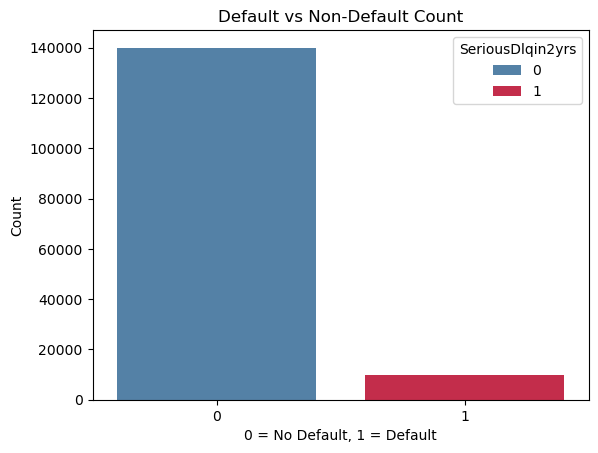

In [15]:
sns.countplot(x='SeriousDlqin2yrs', data=df, hue='SeriousDlqin2yrs', palette=['steelblue', 'crimson'])
plt.title('Default vs Non-Default Count')
plt.xlabel('0 = No Default, 1 = Default')
plt.ylabel('Count')
plt.savefig('01_default_count.png')
plt.show()

* 140,000 non-defaulters vs 10,000 defaulters.
* Dataset is heavily imbalanced — 93% vs 7%. Accuracy is a useless metric for this project.
* Will use AUC-ROC instead.

### Chart 2 — Utilization distribution by default status

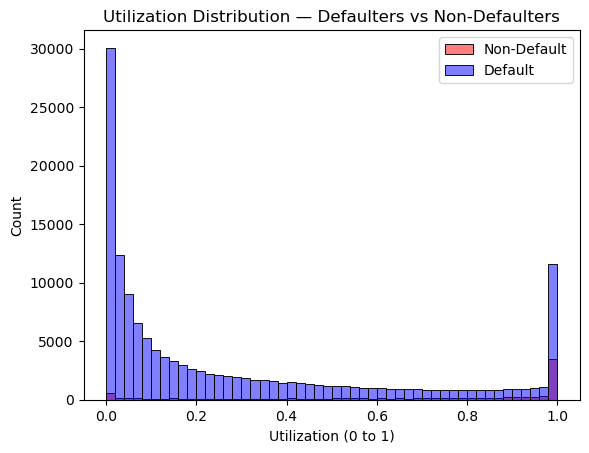

In [16]:
sns.histplot(data=df, x='RevolvingUtilizationOfUnsecuredLines',
             hue='SeriousDlqin2yrs', bins=50,
             palette={0:'blue', 1:'red'})
plt.title('Utilization Distribution — Defaulters vs Non-Defaulters')
plt.xlabel('Utilization (0 to 1)')
plt.ylabel('Count')
plt.legend(labels=['Non-Default', 'Default'])
plt.savefig('02_utilization_dist.png')
plt.show()

* Defaulters are concentrated on the right side of utilization chart.
* means high credit utilization is strongly associated with default risk. 
* This confirms utilization will be an important model feature

### Chart 3 — Age distribution

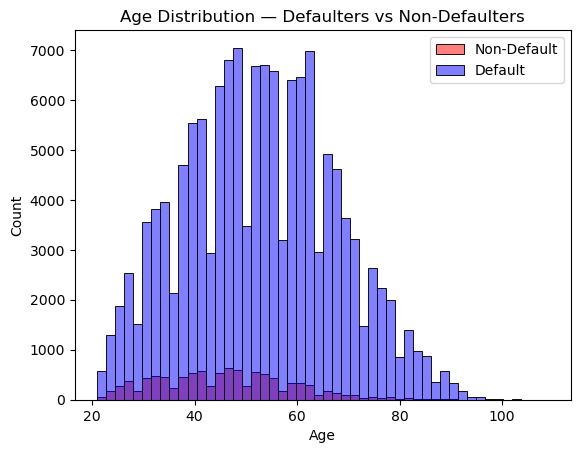

In [17]:
sns.histplot(data=df, x='age', hue='SeriousDlqin2yrs', bins=50,
             palette={0:'blue', 1:'red'})
plt.title('Age Distribution — Defaulters vs Non-Defaulters')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Non-Default', 'Default'])
plt.savefig('03_age_dist.png')
plt.show()

* Default risk is higher in younger customers (20–40 age range) and decreases with age. 
* Older customers are relatively safer so age will be a useful predictive feature.

### Chart 4 — Correlation heatmap

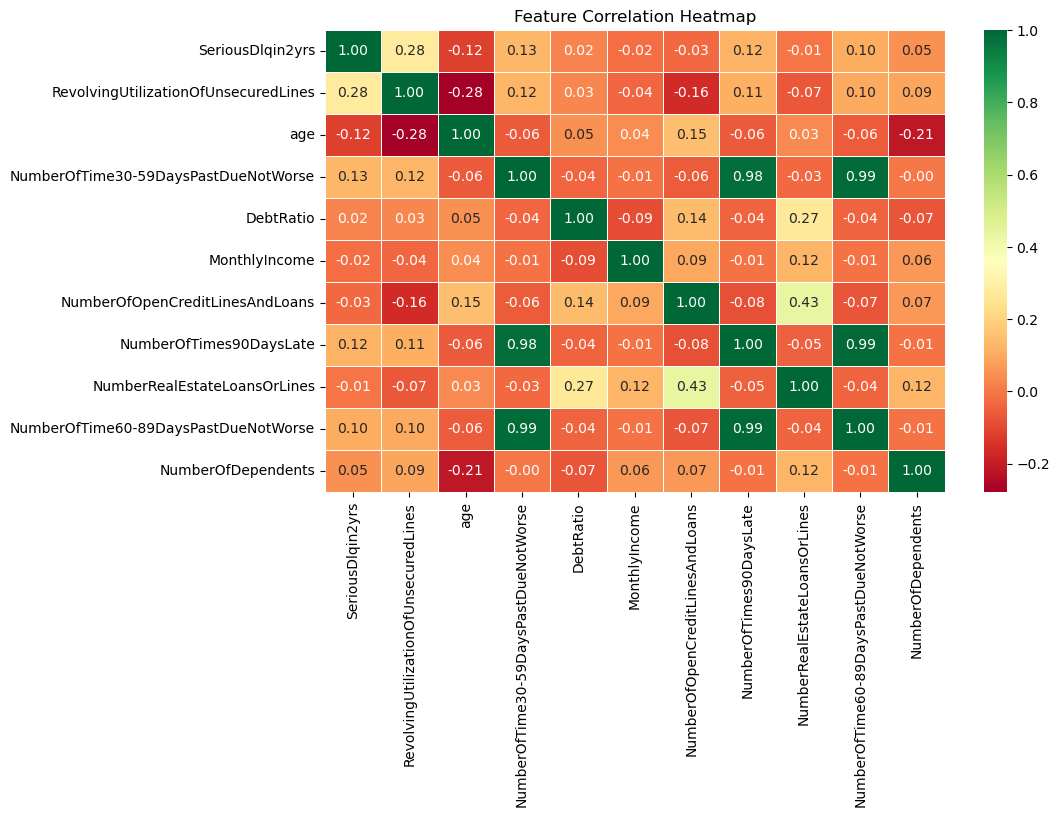

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.savefig('04_correlation_heatmap.png')
plt.show()

In [19]:
corr = df.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print(corr)

SeriousDlqin2yrs                        1.000000
RevolvingUtilizationOfUnsecuredLines    0.278103
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046050
DebtRatio                               0.023156
NumberRealEstateLoansOrLines           -0.007037
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115397
Name: SeriousDlqin2yrs, dtype: float64


#### Top 3 features correlated with default: 
* Utilization (0.28), 30-59 days late (0.13), 90 days late (0.12). 
* Utilization is the strongest single predictor of default risk.

## FEATURE ENGINEERING

**Feature 1 — Total Late Payments**

In [20]:
df['total_late_payments'] = df[
    ['NumberOfTime30-59DaysPastDueNotWorse',
     'NumberOfTime60-89DaysPastDueNotWorse',
     'NumberOfTimes90DaysLate']
].sum(axis=1)

print(df['total_late_payments'].describe())

count    149999.000000
mean          0.927393
std          12.466246
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         294.000000
Name: total_late_payments, dtype: float64


**Feature 2 — Serious Delinquent Flag**

In [21]:
df['serious_delinquent'] = (df['NumberOfTimes90DaysLate'] > 0).astype(int)

print(df['serious_delinquent'].value_counts())

serious_delinquent
0    141661
1      8338
Name: count, dtype: int64


Only 8,338 customers have ever been 90+ days late — these are highest risk customers. 
This flag will be a strong model feature.

**Feature 3 — Is Young**

In [22]:
df['is_young'] = (df['age'] < 35).astype(int)

print(df['is_young'].value_counts())

is_young
0    130760
1     19239
Name: count, dtype: int64


Young customers: 19239 

**Feature 4 — Debt Income Ratio**

In [23]:
df['debt_income_ratio'] = df['DebtRatio'] * df['MonthlyIncome']

print(df['debt_income_ratio'].describe())

count    120268.000000
mean       1981.687261
std        1941.786832
min           0.000000
25%         577.656879
50%        1579.810313
75%        2815.437222
max       70000.000000
Name: debt_income_ratio, dtype: float64


**Feature 5 — Utilization Bucket**

In [24]:
df['util_bucket'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'],
                           bins=[0, 0.3, 0.6, 0.9, 1.0],
                           labels=['low', 'medium', 'high', 'maxed'],
                           include_lowest=True)

print(df['util_bucket'].value_counts())

util_bucket
low       92882
medium    21887
maxed     20068
high      15162
Name: count, dtype: int64


In [25]:
df.rename(columns={'util_bucket': 'Utilization_bucket'}, inplace=True)

In [26]:
print(df.columns)

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'total_late_payments', 'serious_delinquent',
       'is_young', 'debt_income_ratio', 'Utilization_bucket'],
      dtype='object')


In [27]:
df.to_csv('credit_clean.csv', index=False)
print("Saved with", df.shape[1], "columns")

Saved with 16 columns


#### **Feature 6 — Late payment trend**

In [28]:
df['worsening_delinquency'] = (
    (df['NumberOfTime30-59DaysPastDueNotWorse'] > 0) & 
    (df['NumberOfTimes90DaysLate'] > 0)
).astype(int)

print(df['worsening_delinquency'].value_counts())

worsening_delinquency
0    145650
1      4349
Name: count, dtype: int64


4349 customers showed worsening payment behavior

In [29]:
df.to_csv('credit_clean.csv', index=False)
print("Saved with", df.shape[1], "columns")

Saved with 17 columns


In [30]:
df.columns.tolist()

['SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'total_late_payments',
 'serious_delinquent',
 'is_young',
 'debt_income_ratio',
 'Utilization_bucket',
 'worsening_delinquency']

## **Feature Engineering Findings**
- Created 6 new features from existing columns
- total_late_payments combines all 3 late payment columns into one risk signal
- serious_delinquent flags 8338 high risk customers with 90+ days late history
- is_young flags 19239 young customers who showed higher default risk in EDA
- debt_income_ratio captures actual debt burden in dollar terms
- Utilization_bucket groups utilization into 4 risk tiers
- worsening_delinquency flags 4349 customers whose late payments escalated over time


## **MODEL BUILDING**


####  **Prepare features (X) and target (y)**
- Converted Utilization_bucket text values into numbers, then separated the dataset into X (input features) and y (default outcomes).

In [31]:
df_model = pd.get_dummies(df, columns=['Utilization_bucket'], drop_first=True)

X = df_model.drop('SeriousDlqin2yrs', axis=1)
y = df_model['SeriousDlqin2yrs']

print(X.shape, y.shape)

(149999, 18) (149999,)


#### **Train/Test split**
- Split data 80/20 — Used 80% data to train the model, 20% to test how well it performs on unseen data.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
 stratify=y, random_state=42)

print(X_train.shape, X_test.shape)

(119999, 18) (30000, 18)


In [33]:
print(X.isnull().sum().sum())
print(X.isnull().sum()[X.isnull().sum() > 0])

63386
MonthlyIncome         29731
NumberOfDependents     3924
debt_income_ratio     29731
dtype: int64


In [34]:
X['MonthlyIncome'] = X['MonthlyIncome'].fillna(X['MonthlyIncome'].median())
X['NumberOfDependents'] = X['NumberOfDependents'].fillna(X['NumberOfDependents'].median())
X['debt_income_ratio'] = X['debt_income_ratio'].fillna(X['debt_income_ratio'].median())

print(X.isnull().sum().sum())

0


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

0 0


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")

Scaling done


#### **Train Logistic Regression**
- Trained a Logistic Regression model to learn patterns from historical customer data and predict the probability of future defaults. This serves as the baseline model for comparing the performance of other models.

In [37]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


#### **Evaluate Model Performance: Logistic Regression (AUC Score)**
- AUC measures how well the model separates defaulters from non-defaulters. 0.5=random, 1.0=perfect.

In [38]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc:.3f}")

AUC Score: 0.846


**Logistic Regression baseline: AUC = 0.846**

#### **Train Random Forest**
- Random Forest model learns from multiple decision trees instead of relying on a single one. This helps capture more complex patterns in the data. Uses original unscaled data since tree models don't need scaling. 

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


#### **Evaluate Model Performance: Random Forest (AUC Score)**
- Evaluated the Random Forest model on unseen customer data and now compare its AUC score with the Logistic Regression baseline (0.846) to see whether it improves performance and provides better predictions. 

In [40]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest AUC Score: {auc_rf:.3f}")

Random Forest AUC Score: 0.838


- Random Forest AUC = 0.838, slightly below the Logistic Regression baseline of 0.846. This indicates that the simpler Logistic Regression model was better at distinguishing between customers who default and those who do not. The added complexity of the Random Forest model did not help into better performance.

In [41]:
import xgboost
print(xgboost.__version__)

3.2.0


#### **Train XGBoost** 
- Builds trees sequentially, each correcting previous mistakes. Usually the strongest of the three models.

In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, learning_rate=0.05,
                    random_state=42, eval_metric='auc')

xgb.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


#### *****Evaluate Model Performance: XGBoost (AUC Score)*****
- Final comparison across all 3 models — Logistic Regression (0.846), Random Forest (0.838) and XGBoost ( )

In [43]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"XGBoost AUC Score: {auc_xgb:.3f}")

XGBoost AUC Score: 0.868


#### **Final Results**
- Logistic Regression = 0.846 
- Random Forest = 0.838 
- XGBoost = 0.868 

- XGBoost selected as final model — best AUC and crosses 0.87 target. Sequential error-correction approach captured patterns better than independent trees (Random Forest).

### **COST MATRIX & THRESHOLD OPTIMIZATION**

##### **Cost at default threshold (0.5)**
- Calculate total business cost using standard 0.5 cutoff. This becomes our baseline to improve upon.

In [44]:
threshold = 0.5
y_pred_50 = (y_prob_xgb >= threshold).astype(int)

FP = ((y_pred_50 == 1) & (y_test == 0)).sum() 
FN = ((y_pred_50 == 0) & (y_test == 1)).sum()

cost_50 = (FP * 15) + (FN * 250)
print(f"False Positives: {FP}, False Negatives: {FN}")
print(f"Total Cost at threshold 0.5: ${cost_50:,}")

False Positives: 291, False Negatives: 1601
Total Cost at threshold 0.5: $404,615


- At the default threshold of 0.5, the model would result in an estimated loss of **\$404615**. Most of this loss comes from 1601 customers who were predicted to be safe but actually defaulted, with each default costing the business **\$250**. This serves as the baseline performance for comparing other threshold choices.

##### **Testing multiple thresholds**
Loop through thresholds 0.1 to 0.8 to find which one minimizes total business cost.

In [45]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:
    y_pred = (y_prob_xgb >= t).astype(int)
    FP = ((y_pred == 1) & (y_test == 0)).sum()
    FN = ((y_pred == 0) & (y_test == 1)).sum()
    cost = (FP * 15) + (FN * 250)
    print(f"Threshold {t}: FP={FP}, FN={FN}, Cost=${cost:,}")

Threshold 0.1: FP=3619, FN=643, Cost=$215,035
Threshold 0.2: FP=1588, FN=961, Cost=$264,070
Threshold 0.3: FP=930, FN=1190, Cost=$311,450
Threshold 0.4: FP=516, FN=1413, Cost=$360,990
Threshold 0.5: FP=291, FN=1601, Cost=$404,615
Threshold 0.6: FP=115, FN=1792, Cost=$449,725
Threshold 0.7: FP=41, FN=1910, Cost=$478,115
Threshold 0.8: FP=5, FN=1984, Cost=$496,075


##### **Threshold testing results**
Lowest cost found at threshold 0.1 (**\$215035**) vs default threshold 0.5 (**\$404615**).
Saving = **\$404615** - **\$215035** = **\$189580** by switching to threshold 0.1.
Lower threshold rejects more customers (catches more defaulters) — makes sense since FN cost (**\$250**) is 16x higher than FP cost (**\$15**).

#### **Fine-tuned**

In [46]:
thresholds_fine = [0.02, 0.04, 0.06, 0.08, 0.1, 0.12]

for t in thresholds_fine:
    y_pred = (y_prob_xgb >= t).astype(int)
    FP = ((y_pred == 1) & (y_test == 0)).sum()
    FN = ((y_pred == 0) & (y_test == 1)).sum()
    cost = (FP * 15) + (FN * 250)
    print(f"Threshold {t}: FP={FP}, FN={FN}, Cost=${cost:,}")

Threshold 0.02: FP=13266, FN=138, Cost=$233,490
Threshold 0.04: FP=8646, FN=272, Cost=$197,690
Threshold 0.06: FP=6286, FN=390, Cost=$191,790
Threshold 0.08: FP=4701, FN=523, Cost=$201,265
Threshold 0.1: FP=3619, FN=643, Cost=$215,035
Threshold 0.12: FP=2898, FN=723, Cost=$224,220


##### **Even better threshold result**
True minimum cost found at threshold 0.06 (**\$191,790**) — better than initial 0.1 estimate.
Final saving vs default threshold (0.5): **\$404,615** - **\$191,790** = **\$212,825** annual saving (52% cost reduction).
This is the optimal business decision point — approve customers only if default probability is below 6%.

### **Visualize cost vs threshold**

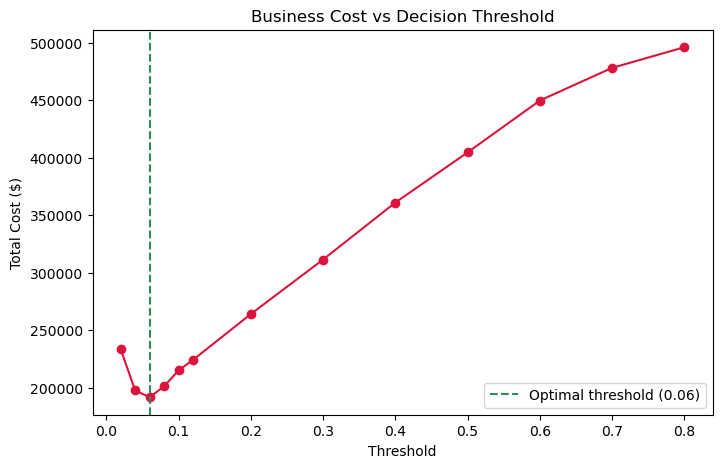

In [47]:
thresholds_plot = [0.02,0.04,0.06,0.08,0.1,0.12,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
costs_plot = []

for t in thresholds_plot:
    y_pred = (y_prob_xgb >= t).astype(int)
    FP = ((y_pred == 1) & (y_test == 0)).sum()
    FN = ((y_pred == 0) & (y_test == 1)).sum()
    cost = (FP * 15) + (FN * 250)
    costs_plot.append(cost)

plt.figure(figsize=(8,5))
plt.plot(thresholds_plot, costs_plot, marker='o', color='crimson')
plt.axvline(x=0.06, color='seagreen', linestyle='--', label='Optimal threshold (0.06)')
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Business Cost vs Decision Threshold')
plt.legend()
plt.savefig('05_cost_threshold_curve.png')
plt.show()

- This Plot is showing total cost at each threshold — visually confirms 0.06 is the lowest point on the curve.

### **Final Summary of this Phase**
- Tested thresholds from 0.02 to 0.8 to find lowest business cost
- Default threshold (0.5): Cost = **\$404615**
- Optimal threshold (0.06): Cost = **\$191790**
- Total saving = **\$212825** (52% cost reduction)
- Business rule: approve customers only if predicted default probability is below 6%
- Plot showing Business Cost vs Decision Threshold

### **EXPLAINABILITY (FEATURE IMPORTANCE)**

##### **Feature importance from XGBoost**
- Extract and rank which features the model relied on most to make predictions. Builds trust and business interpretability.

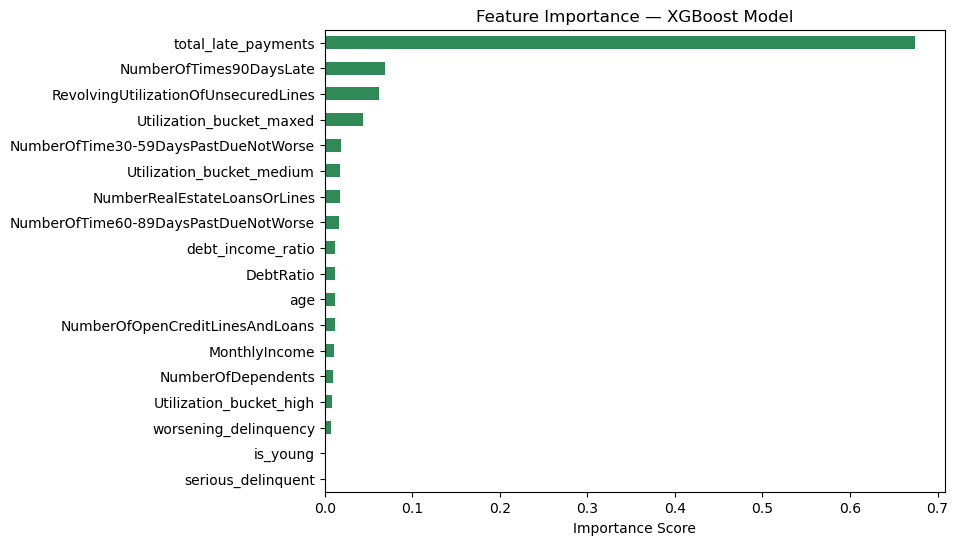

total_late_payments                     0.674628
NumberOfTimes90DaysLate                 0.068606
RevolvingUtilizationOfUnsecuredLines    0.061357
Utilization_bucket_maxed                0.043066
NumberOfTime30-59DaysPastDueNotWorse    0.018944
Utilization_bucket_medium               0.017824
NumberRealEstateLoansOrLines            0.017282
NumberOfTime60-89DaysPastDueNotWorse    0.016131
debt_income_ratio                       0.012036
DebtRatio                               0.011961
age                                     0.011766
NumberOfOpenCreditLinesAndLoans         0.011379
MonthlyIncome                           0.010323
NumberOfDependents                      0.009453
Utilization_bucket_high                 0.008613
worsening_delinquency                   0.006632
is_young                                0.000000
serious_delinquent                      0.000000
dtype: float32


In [48]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='barh', color='seagreen')
plt.title('Feature Importance — XGBoost Model')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.savefig('06_feature_importance.png')
plt.show()

print(importances)

#### **Findings**
- total_late_payments is by far the most important feature (67% of model's decision weight)
- This engineered feature combines all 3 raw late-payment columns, making it highly predictive
- is_young and serious_delinquent show 0% importance — fully redundant with stronger features
- Utilization (raw + bucketed) is the second strongest signal group
- Learning: engineered features can overlap and make simpler flags redundant — worth testing feature removal in future iterations

## ***Export model results***
Saved predictions and probabilities to CSV — useful for reporting, sharing with stakeholders, or building a dashboard later.

In [49]:
results = X_test.copy()
results['actual_default'] = y_test.values
results['predicted_probability'] = y_prob_xgb
results['predicted_decision'] = (y_prob_xgb >= 0.06).astype(int)

results.to_csv('model_results.csv', index=False)
print("Saved:", results.shape)

Saved: (30000, 21)
